In [1]:
import pandas as pd

data = [
    {"mode": "car_petrol", "unit": "km", "emission_factor": 0.225},
    {"mode": "car_diesel", "unit": "km", "emission_factor": 0.201},
    {"mode": "bus", "unit": "passenger-km", "emission_factor": 0.088},
    {"mode": "motorbike", "unit": "km", "emission_factor": 0.112},
    {"mode": "delivery_van", "unit": "km", "emission_factor": 0.315},
]

df_factors = pd.DataFrame(data)
df_factors.to_csv("transport_emission_factors.csv", index=False)

print("transport_emission_factors.csv created")
print(df_factors)


transport_emission_factors.csv created
           mode          unit  emission_factor
0    car_petrol            km            0.225
1    car_diesel            km            0.201
2           bus  passenger-km            0.088
3     motorbike            km            0.112
4  delivery_van            km            0.315


In [2]:
import pandas as pd
import random

businesses = [
    {"business_id": "B0001", "business_type": "Bakery"},
    {"business_id": "B0002", "business_type": "Restaurant"},
    {"business_id": "B0003", "business_type": "Supermarket"},
    {"business_id": "B0004", "business_type": "Pharmacy"},
    {"business_id": "B0005", "business_type": "FuelStation"},
]

modes = ["car_petrol", "car_diesel", "bus", "motorbike", "delivery_van"]

records = []
months = pd.date_range("2024-01-01", "2024-12-01", freq="MS")

for biz in businesses:
    for month in months:
        for _ in range(random.randint(2, 5)):  # trips per month
            mode = random.choice(modes)
            distance = round(random.uniform(10, 300), 1)  # trip length (km)

            if mode == "bus":
                passengers = random.randint(1, 15)  # simulate staff using minibuses
                passenger_km = distance * passengers
                records.append({
                    "business_id": biz["business_id"],
                    "business_type": biz["business_type"],
                    "date": month.strftime("%Y-%m"),
                    "mode": mode,
                    "distance_km": passenger_km,  # store as passenger-km
                })
            else:
                records.append({
                    "business_id": biz["business_id"],
                    "business_type": biz["business_type"],
                    "date": month.strftime("%Y-%m"),
                    "mode": mode,
                    "distance_km": distance,
                })

df_transport = pd.DataFrame(records)
df_transport.to_csv("transport.csv", index=False)

print("transport.csv created with", len(df_transport), "rows")
print(df_transport.head(10))


transport.csv created with 220 rows
  business_id business_type     date          mode  distance_km
0       B0001        Bakery  2024-01    car_diesel         87.6
1       B0001        Bakery  2024-01    car_diesel        275.6
2       B0001        Bakery  2024-01     motorbike         38.6
3       B0001        Bakery  2024-01    car_petrol         83.1
4       B0001        Bakery  2024-01  delivery_van        196.9
5       B0001        Bakery  2024-02           bus       2142.0
6       B0001        Bakery  2024-02    car_petrol         69.7
7       B0001        Bakery  2024-02  delivery_van         79.5
8       B0001        Bakery  2024-02    car_petrol        158.8
9       B0001        Bakery  2024-02    car_diesel         31.0


In [4]:
df_transport.head(20)

,business_id,business_type,date,mode,distance_km
0,B0001,Bakery,2024-01,car_diesel,87.6
1,B0001,Bakery,2024-01,car_diesel,275.6
2,B0001,Bakery,2024-01,motorbike,38.6
3,B0001,Bakery,2024-01,car_petrol,83.1
4,B0001,Bakery,2024-01,delivery_van,196.9
5,B0001,Bakery,2024-02,bus,2142.0
6,B0001,Bakery,2024-02,car_petrol,69.7
7,B0001,Bakery,2024-02,delivery_van,79.5
8,B0001,Bakery,2024-02,car_petrol,158.8
9,B0001,Bakery,2024-02,car_diesel,31.0


In [5]:
# --- LOAD DATA ---
transport = pd.read_csv("transport.csv")
factors = pd.read_csv("transport_emission_factors.csv")

# --- MERGE ON MODE ---
df_transport = transport.merge(factors, how="left", on="mode")

# --- CALCULATE EMISSIONS ---
df_transport["emissions_kgCO2e"] = df_transport["distance_km"] * df_transport["emission_factor"]

# --- SAVE OUTPUT ---
df_transport.to_csv("transport_emissions_summary.csv", index=False)

print("transport_emissions_summary.csv created with", len(df_transport), "rows")
print(df_transport.head(10))


transport_emissions_summary.csv created with 220 rows
  business_id business_type     date          mode  distance_km          unit  \
0       B0001        Bakery  2024-01    car_diesel         87.6            km   
1       B0001        Bakery  2024-01    car_diesel        275.6            km   
2       B0001        Bakery  2024-01     motorbike         38.6            km   
3       B0001        Bakery  2024-01    car_petrol         83.1            km   
4       B0001        Bakery  2024-01  delivery_van        196.9            km   
5       B0001        Bakery  2024-02           bus       2142.0  passenger-km   
6       B0001        Bakery  2024-02    car_petrol         69.7            km   
7       B0001        Bakery  2024-02  delivery_van         79.5            km   
8       B0001        Bakery  2024-02    car_petrol        158.8            km   
9       B0001        Bakery  2024-02    car_diesel         31.0            km   

   emission_factor  emissions_kgCO2e  
0            0.

In [6]:
df_transport.head(20)

,business_id,business_type,date,mode,distance_km,unit,emission_factor,emissions_kgCO2e
0,B0001,Bakery,2024-01,car_diesel,87.6,km,0.201,17.6076
1,B0001,Bakery,2024-01,car_diesel,275.6,km,0.201,55.3956
2,B0001,Bakery,2024-01,motorbike,38.6,km,0.112,4.3232
3,B0001,Bakery,2024-01,car_petrol,83.1,km,0.225,18.6975
4,B0001,Bakery,2024-01,delivery_van,196.9,km,0.315,62.0235
5,B0001,Bakery,2024-02,bus,2142.0,passenger-km,0.088,188.4960
6,B0001,Bakery,2024-02,car_petrol,69.7,km,0.225,15.6825
7,B0001,Bakery,2024-02,delivery_van,79.5,km,0.315,25.0425
8,B0001,Bakery,2024-02,car_petrol,158.8,km,0.225,35.7300
9,B0001,Bakery,2024-02,car_diesel,31.0,km,0.201,6.2310


In [7]:
df_transport.to_csv("transport_emissions_summary.csv", index=False)

from google.colab import files
files.download("transport_emissions_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Dataset Shape: (220, 8)

Columns: ['business_id', 'business_type', 'date', 'mode', 'distance_km', 'unit', 'emission_factor', 'emissions_kgCO2e']

Preview:
   business_id business_type     date          mode  distance_km unit  \
0       B0001        Bakery  2024-01    car_diesel         87.6   km   
1       B0001        Bakery  2024-01    car_diesel        275.6   km   
2       B0001        Bakery  2024-01     motorbike         38.6   km   
3       B0001        Bakery  2024-01    car_petrol         83.1   km   
4       B0001        Bakery  2024-01  delivery_van        196.9   km   

   emission_factor  emissions_kgCO2e  
0            0.201           17.6076  
1            0.201           55.3956  
2            0.112            4.3232  
3            0.225           18.6975  
4            0.315           62.0235  

Summary Stats:
       business_id business_type     date          mode  distance_km unit  \
count          220           220      220           220   220.000000  220   
unique 

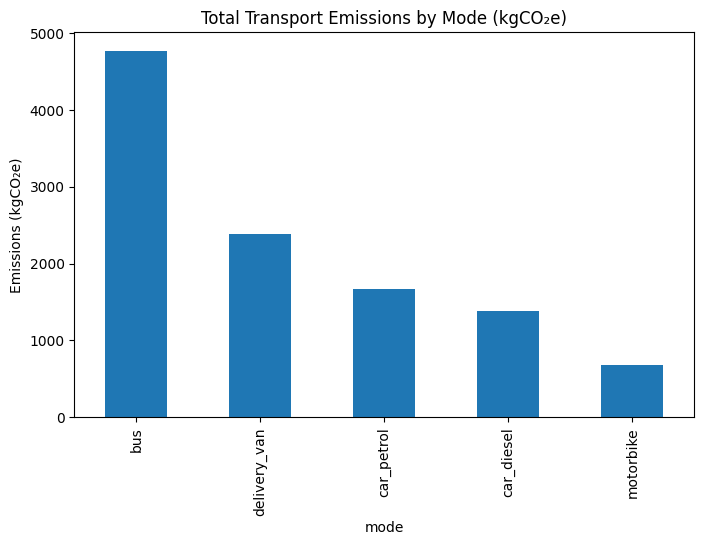


Total emissions by business type:
 business_type
Supermarket    2410.7757
Restaurant     2348.1000
Bakery         2308.4543
FuelStation    1978.8932
Pharmacy       1851.0605
Name: emissions_kgCO2e, dtype: float64


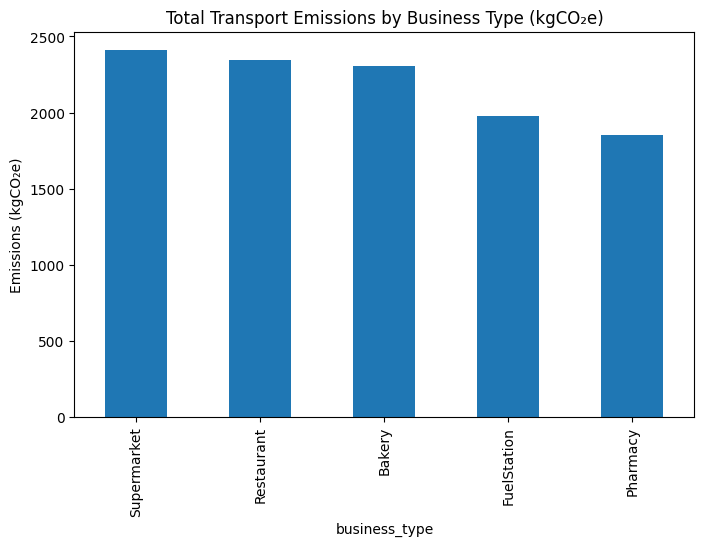

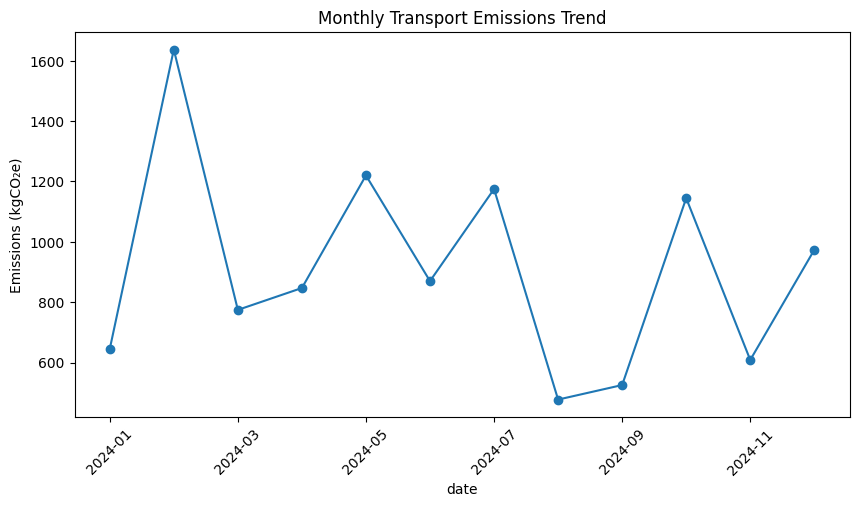

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load processed transport data
df_transport = pd.read_csv("transport_emissions_summary.csv")

print("Dataset Shape:", df_transport.shape)
print("\nColumns:", df_transport.columns.tolist())
print("\nPreview:\n", df_transport.head())

# --- Basic summary stats ---
print("\nSummary Stats:")
print(df_transport.describe(include="all"))

# --- Emissions by mode ---
emissions_by_mode = df_transport.groupby("mode")["emissions_kgCO2e"].sum().sort_values(ascending=False)
print("\nTotal emissions by mode:\n", emissions_by_mode)

emissions_by_mode.plot(kind="bar", figsize=(8,5), title="Total Transport Emissions by Mode (kgCO₂e)")
plt.ylabel("Emissions (kgCO₂e)")
plt.show()

# --- Emissions by business type ---
emissions_by_biz = df_transport.groupby("business_type")["emissions_kgCO2e"].sum().sort_values(ascending=False)
print("\nTotal emissions by business type:\n", emissions_by_biz)

emissions_by_biz.plot(kind="bar", figsize=(8,5), title="Total Transport Emissions by Business Type (kgCO₂e)")
plt.ylabel("Emissions (kgCO₂e)")
plt.show()

# --- Monthly emissions trend ---
monthly_emissions = df_transport.groupby("date")["emissions_kgCO2e"].sum()
monthly_emissions.plot(figsize=(10,5), marker="o", title="Monthly Transport Emissions Trend")
plt.ylabel("Emissions (kgCO₂e)")
plt.xticks(rotation=45)
plt.show()




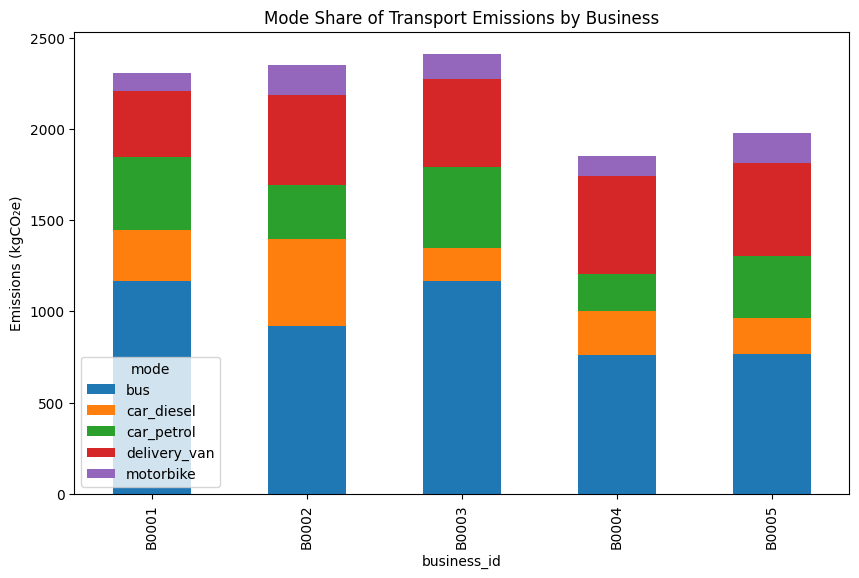

In [10]:
# --- Mode share per business (stacked bar) ---
pivot = df_transport.pivot_table(index="business_id", columns="mode", values="emissions_kgCO2e", aggfunc="sum", fill_value=0)
pivot.plot(kind="bar", stacked=True, figsize=(10,6), title="Mode Share of Transport Emissions by Business")
plt.ylabel("Emissions (kgCO₂e)")
plt.show()